<small>
Copyright 2026 Google LLC.<br>
Licensed under the Apache License, Version 2.0.
</small>
<details><pre>
Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
</pre></details>

# Parallel Random Circuit Sampling (RCS) & XEB Analysis

This notebook serves as an end-to-end tutorial for generating, executing, and analyzing Random Circuit Sampling (RCS) experiments using the framework within ReCirq. Because full-chip quantum simulations are computationally expensive, this guide demonstrates how to use local verification on smaller sub-grids to calculate overall system performance for noisy simulation. We then run the circuits on actual quantum hardware through [Quantum Engine](https://quantumai.google/cirq/google/engine) and compare to the noisy simulations.

Throughout this notebook, we will walk through the following core workflow:

* **Defining Qubit Patches:** Partitioning a larger system into disjoint, non-overlapping sub-grids.
* **Configuring the Noiseless Simulation:** Executing a noiseless simulation to establish ideal Cross-Entropy Benchmarking (XEB) fidelities.
* **Configuring the Noisy Simulation using measured error rates:** Utilizing a noise model configured with realistic device noise properties to simulate actual hardware execution.
* **Analyzing & Visualizing Results:** Calculating individual patch fidelities and total system fidelity for noisy simulations, and plotting the results to show fidelity decay caused by accumulated noise.
* **Hardware demo:** Performing the same data taking and analysis on actual quantum hardware and comparing against the simulation.

In [ ]:
# To run this notebook in Google Colab, uncomment and run the following line:
#!pip install cirq cirq_google qsimcirq

# To install the local 'recirq' package from the repository:
# 1. Clone the repo: !git clone https://github.com/quantumlib/ReCirq.git
# 2. Install: !pip install -e ReCirq/
# 3. IMPORTANT: Restart the Colab runtime (Runtime > Restart session) after installation.

# Imports

In [2]:
import cirq
import cirq_google
import qsimcirq
import recirq.random_circuit_sampling as rcs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker

# Define the patches

Patches serve as a tool for local verification and benchmarking. By partitioning the processor into non-overlapping sub-grids, we can use classical simulators to compute exact ideal states that would be computationally impossible at full-chip scale. This also allows us to characterize local noise profiles within specific hardware regions. Finally, we can estimate the overall fidelity of the larger system by calculating the product of the fidelities from these independent patches.

Select sets of connected qubits to serve as patches. These patches must be disjoint and should not share any common qubits.

In [3]:
patch_1 = cirq.GridQubit.rect(3,3,3,3)
patch_2 = cirq.GridQubit.rect(3,3,3,6)
patch_3 = cirq.GridQubit.rect(3,3,6,6)
patch_4 = cirq.GridQubit.rect(3,3,6,3)

patches = [patch_1, patch_2, patch_3, patch_4]
qubits = []
for patch in patches:
    qubits += patch

## Set up and run the experiment

Specify the qubit patches and the desired circuit depths for XEB calculation. Additionally, define the number of random circuit instances per configuration and the specific tiling pattern for the experiment. While the framework supports characterizing the fSim gate parameters ($\theta, \phi, \zeta, \chi, \gamma$), this step is bypassed here as we are performing an ideal noiseless simulation.

In [4]:
depths=[10, 12, 14, 16, 18, 20]
num_instances = 100
experiment = rcs.RCSExperiment(
    patches=patches,
    depths=depths,
    num_instances=num_instances,
    pattern_name="staggered",
    seed= 2026
)

## Noiseless simulation

In [5]:
results = experiment.run(sampler=cirq.Simulator(), n_repetitions=1000, characterize=False)

Running 600 zipped instances on 4 parallel patches...


## Calculate linear XEB fidelities

To calculate fidelities via noiseless simulation, we can employ the standard `cirq.Simulator()`. Here, we use the performance-optimized `qsimcirq.QSimSimulator()` to improve execution efficiency.


In [6]:
fidelities = results.fidelities_lin(simulator=qsimcirq.QSimSimulator())

XEB Analysis: 100%|████████████████████████| 2400/2400 [00:12<00:00, 187.81it/s]


## Plot the results

Visualize the XEB results for each patch across the specified circuit depths. The plot reflects the mean fidelity calculated across all random circuit instances for each (patch, depth) configuration.

Note on ideal vs. noisy simulation: You might notice that the plotted linear XEB fidelity is flat at around 1.0 across all circuit depths. This behavior is exactly what we expect from an ideal, noiseless simulation. In a real quantum hardware experiment (or a noisy simulation), incoherent errors and decoherence accumulate at each gate layer, resulting in a characteristic exponential decay curve as the circuit gets deeper. Since our simulated qubits do not suffer from any noise, the fidelity remains at ~1.0 (with statsitical fluctuations resulting purely from finite sampling variance across our 1000 repetitions and 100 random circuits). To decrease the fluctuations, you could run it using 1000 random circuits, but would take longer to run. See the next section for a noisy simulation.

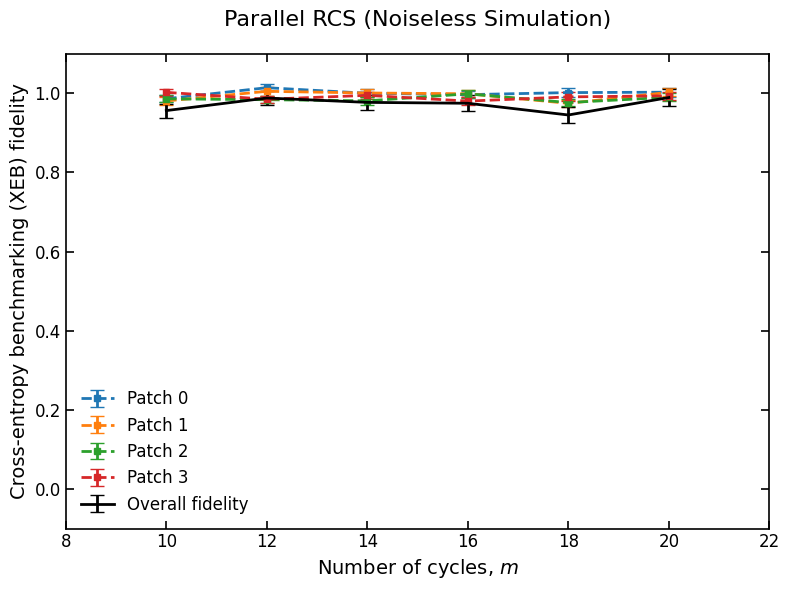

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Process and plot individual patches

means_matrix = np.zeros((len(patches), len(depths)))
errs_matrix = np.zeros((len(patches), len(depths)))
for i in range(len(patches)):
    y_means = []
    y_errs = []
    for j, d in enumerate(depths):
        fids = fidelities[(i, d)]
        mean_val = np.mean(fids)
        err_val = np.std(fids, ddof=1) / np.sqrt(num_instances)
        y_means.append(mean_val)
        y_errs.append(err_val)
        means_matrix[i, j] = mean_val
        errs_matrix[i, j] = err_val


    ax.errorbar(
        experiment.depths,
        means_matrix[i],
        yerr=errs_matrix[i],
        marker='s',
        markersize=4,
        linewidth=2,
        label=f'Patch {i}',
        linestyle='--',
        capsize=5,
        color=f'C{i}'
    )


# 2. Process and plot overall fidelity
overall_means = []
overall_errs = []

for j in range(len(depths)):
    f_tot = np.prod(means_matrix[:, j])
    overall_means.append(f_tot)

    # Error propagation
    rel_errors_sq = (errs_matrix[:, j] / means_matrix[:, j])**2
    err_tot = f_tot * np.sqrt(np.sum(rel_errors_sq))
    overall_errs.append(err_tot)

ax.errorbar(depths, overall_means, yerr=overall_errs, markersize=5,
            linewidth=2, label='Overall fidelity', linestyle='solid', color='k', capsize=5)


ax.set_ylim(-0.1, 1.1)
ax.set_xlim(min(experiment.depths) - 2, max(experiment.depths) + 2)
ax.set_xlabel(r'Number of cycles, $m$', fontsize=14)
ax.set_ylabel('Cross-entropy benchmarking (XEB) fidelity', fontsize=14)
ax.set_title('Parallel RCS (Noiseless Simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()

# Noisy simulation

We perform noisy simulations using a custom noise model. The resulting XEB fidelity plot demonstrates the fidelity decay as circuit depth increases, reflecting the accumulation of errors in a noisy system.

In [ ]:
# reload the experiment so as to use the same seed for comparison
experiment_sim = rcs.RCSExperiment(
    patches=patches,
    depths=depths,
    num_instances=100,
    pattern_name="staggered",
    seed= 2026,
    two_qubit_gate = cirq.PhasedFSimGate(theta=np.pi/2, zeta=0.14, chi = 0.0003, gamma = -0.005, phi=0.377)
)

### Define the error channels that we will simulate.

We will include single- and two-qubit gate errors, asymmetric readout errors, and $T_1$ decay during idling time.

In [ ]:
from typing import Sequence

class AsymmetricReadoutChannel(cirq.Gate):
    def __init__(self, p01: float, p10: float):
        """
        Args:
            p01: Probability of reading 0 when the true state is 1
            p10: Probability of reading 1 when the true state is 0
        """
        self.p01 = float(p01)
        self.p10 = float(p10)

    def _num_qubits_(self) -> int:
        return 1

    def _kraus_(self):
        k0 = np.array([[np.sqrt(1 - self.p10), 0], [0, 0]])
        k1 = np.array([[0, 0], [np.sqrt(self.p10), 0]])
        k2 = np.array([[0, np.sqrt(self.p01)], [0, 0]])
        k3 = np.array([[0, 0], [0, np.sqrt(1 - self.p01)]])
        return [k0, k1, k2, k3]

    def _has_kraus_(self):
        return True


class HardwareTargetedAsymmetricNoise(cirq.NoiseModel):
    def __init__(self,
                 single_errors: dict,
                 two_errors: dict,
                 zero_measurement_error: dict,
                 one_measurement_error: dict,
                 idle_gammas: dict):
        """
        Args:
            single_errors: single-qubit Pauli error rates
            two_errors: two-qubit Pauli error rates
            zero_measurement_error: 0->1 readout errors
            one_measurement_error: 1->0 readout errors
            idle_gammas: decay probability while a qubit is idling
        """
        self.single_errors = single_errors
        self.two_errors = two_errors
        self.zero_measurement_error = zero_measurement_error
        self.one_measurement_error = one_measurement_error
        self.idle_gammas = idle_gammas

    def noisy_operation(self, operation: cirq.Operation):
        # --------------------------------------------------------
        # 1. MEASUREMENT GATES
        # --------------------------------------------------------
        if cirq.is_measurement(operation):
            # Yield readout noise BEFORE the measurement
            for q in operation.qubits:

                p10 = self.zero_measurement_error.get(q, 0.0)
                p01 = self.one_measurement_error.get(q, 0.0)

                if p01 > 0 or p10 > 0:
                    yield AsymmetricReadoutChannel(p01, p10).on(q)

            # Now yield the actual measurement
            yield operation
            return

        # --------------------------------------------------------
        # 2. STANDARD GATES
        # --------------------------------------------------------
        # Yield the gate operation first
        yield operation

        # Then apply the depolarizing noise AFTER the gate
        num_qubits = len(operation.qubits)

        if num_qubits == 1:
            q = operation.qubits[0]

            p = self.single_errors.get(q, 0.0)
            if p > 0:
                yield cirq.depolarize(float(p)).on(q)

        elif num_qubits == 2:
            q1, q2 = operation.qubits

            p = self.two_errors.get(
                (q1, q2),
                self.two_errors.get((q2, q1), 0.0)
            )
            if p > 0:
                yield cirq.depolarize(float(p), n_qubits=2).on(q1, q2)

    def noisy_moment(self, moment: cirq.Moment, system_qubits: Sequence[cirq.Qid]):
        # 1. Always yield the original moment first so the intended gates execute
        for op in moment.operations:
            yield self.noisy_operation(op)

        # 2. Identify which qubits are NOT participating in the current moment
        idle_qubits = set(system_qubits) - set(moment.qubits)

        # 3. Apply the amplitude damping channel to all idle qubits
        idle_noise_ops = []
        for q in idle_qubits:
            # Look up the specific gamma for this qubit, defaulting to 0.0 if not found
            gamma = self.idle_gammas.get(q, 0.0)

            if gamma > 0:
                idle_noise_ops.append(cirq.amplitude_damp(gamma).on(q))

        if idle_noise_ops:
            yield idle_noise_ops

### Define the error rates.

These error rates were benchmarked on the device on which we will take the hardware data. The averages are:
* $0\to 1$ readout errors: 0.34%
* $1\to 0$ readout errors: 0.91%
* Single-qubit Pauli errors: 0.046%
* Two-qubit Pauli errors: 0.29%

In [ ]:
zero_measurement_error = {cirq.GridQubit(3, 3): 0.003475000000000006,
 cirq.GridQubit(3, 4): 0.0024250000000000105,
 cirq.GridQubit(3, 5): 0.002929999999999988,
 cirq.GridQubit(4, 3): 0.0037199999999999456,
 cirq.GridQubit(4, 4): 0.00383,
 cirq.GridQubit(4, 5): 0.0031799999999999606,
 cirq.GridQubit(5, 3): 0.00275000000000003,
 cirq.GridQubit(5, 4): 0.001574999999999993,
 cirq.GridQubit(5, 5): 0.0018299999999999983,
 cirq.GridQubit(3, 6): 0.004475000000000007,
 cirq.GridQubit(3, 7): 0.0015899999999999803,
 cirq.GridQubit(3, 8): 0.0019200000000000328,
 cirq.GridQubit(4, 6): 0.0013499999999999623,
 cirq.GridQubit(4, 7): 0.011750000000000038,
 cirq.GridQubit(4, 8): 0.0019599999999999618,
 cirq.GridQubit(5, 6): 0.01281500000000002,
 cirq.GridQubit(5, 7): 0.0013900000000000023,
 cirq.GridQubit(5, 8): 0.003669999999999951,
 cirq.GridQubit(6, 6): 0.0022649999999999615,
 cirq.GridQubit(6, 7): 0.002990000000000048,
 cirq.GridQubit(6, 8): 0.0027199999999999447,
 cirq.GridQubit(7, 6): 0.0017599999999999838,
 cirq.GridQubit(7, 7): 0.0019799999999999818,
 cirq.GridQubit(7, 8): 0.005024999999999946,
 cirq.GridQubit(8, 6): 0.0012050000000000116,
 cirq.GridQubit(8, 7): 0.0023800000000000487,
 cirq.GridQubit(8, 8): 0.0028799999999999937,
 cirq.GridQubit(6, 3): 0.0022900000000000142,
 cirq.GridQubit(6, 4): 0.003469999999999973,
 cirq.GridQubit(6, 5): 0.010264999999999969,
 cirq.GridQubit(7, 3): 0.0041400000000000325,
 cirq.GridQubit(7, 4): 0.0019299999999999873,
 cirq.GridQubit(7, 5): 0.001654999999999962,
 cirq.GridQubit(8, 3): 0.005950000000000011,
 cirq.GridQubit(8, 4): 0.0015849999999999476,
 cirq.GridQubit(8, 5): 0.0024600000000000177}
one_measurement_error = {cirq.GridQubit(3, 3): 0.005179999999999962,
 cirq.GridQubit(3, 4): 0.012475000000000014,
 cirq.GridQubit(3, 5): 0.005955000000000044,
 cirq.GridQubit(4, 3): 0.019405000000000006,
 cirq.GridQubit(4, 4): 0.00686500000000001,
 cirq.GridQubit(4, 5): 0.007310000000000039,
 cirq.GridQubit(5, 3): 0.005739999999999967,
 cirq.GridQubit(5, 4): 0.012624999999999997,
 cirq.GridQubit(5, 5): 0.005085000000000006,
 cirq.GridQubit(3, 6): 0.014935000000000032,
 cirq.GridQubit(3, 7): 0.005305000000000004,
 cirq.GridQubit(3, 8): 0.005985000000000018,
 cirq.GridQubit(4, 6): 0.006480000000000041,
 cirq.GridQubit(4, 7): 0.014660000000000006,
 cirq.GridQubit(4, 8): 0.006879999999999997,
 cirq.GridQubit(5, 6): 0.022700000000000053,
 cirq.GridQubit(5, 7): 0.005909999999999971,
 cirq.GridQubit(5, 8): 0.0065150000000000485,
 cirq.GridQubit(6, 6): 0.007445000000000035,
 cirq.GridQubit(6, 7): 0.006310000000000038,
 cirq.GridQubit(6, 8): 0.005325000000000024,
 cirq.GridQubit(7, 6): 0.005434999999999968,
 cirq.GridQubit(7, 7): 0.007120000000000015,
 cirq.GridQubit(7, 8): 0.008915000000000006,
 cirq.GridQubit(8, 6): 0.007299999999999973,
 cirq.GridQubit(8, 7): 0.007430000000000048,
 cirq.GridQubit(8, 8): 0.00682499999999997,
 cirq.GridQubit(6, 3): 0.00988,
 cirq.GridQubit(6, 4): 0.012994999999999979,
 cirq.GridQubit(6, 5): 0.012745000000000006,
 cirq.GridQubit(7, 3): 0.01982499999999998,
 cirq.GridQubit(7, 4): 0.008549999999999947,
 cirq.GridQubit(7, 5): 0.005924999999999958,
 cirq.GridQubit(8, 3): 0.009220000000000006,
 cirq.GridQubit(8, 4): 0.007284999999999986,
 cirq.GridQubit(8, 5): 0.010985000000000023}


# Note: single- and two-qubit gate errors are Pauli errors
sq_rb_error = {cirq.GridQubit(3, 3): 0.00036299417098442643,
 cirq.GridQubit(3, 4): 0.0003151232903715606,
 cirq.GridQubit(3, 5): 0.00025276005421182024,
 cirq.GridQubit(4, 3): 0.00031154484874013066,
 cirq.GridQubit(4, 4): 0.0005419156445040652,
 cirq.GridQubit(4, 5): 0.00041473008166187375,
 cirq.GridQubit(5, 3): 0.00040572403811461877,
 cirq.GridQubit(5, 4): 0.00040327403158429975,
 cirq.GridQubit(5, 5): 0.0003558049147037168,
 cirq.GridQubit(3, 6): 0.0007386811310649555,
 cirq.GridQubit(3, 7): 0.0004997688843524084,
 cirq.GridQubit(3, 8): 0.0003939176586215676,
 cirq.GridQubit(4, 6): 0.0005583679672660491,
 cirq.GridQubit(4, 7): 0.00033356268901379993,
 cirq.GridQubit(4, 8): 0.00018463773473376133,
 cirq.GridQubit(5, 6): 0.0008581743383332952,
 cirq.GridQubit(5, 7): 0.00028839402369387757,
 cirq.GridQubit(5, 8): 0.0003752641805549739,
 cirq.GridQubit(6, 6): 0.00043792810721013375,
 cirq.GridQubit(6, 7): 0.00036158666773905557,
 cirq.GridQubit(6, 8): 0.00038601890498057845,
 cirq.GridQubit(7, 6): 0.00047163390127094584,
 cirq.GridQubit(7, 7): 0.0002925024785367103,
 cirq.GridQubit(7, 8): 0.0008378045867679651,
 cirq.GridQubit(8, 6): 0.0003366424184771677,
 cirq.GridQubit(8, 7): 0.0007436021349879751,
 cirq.GridQubit(8, 8): 0.0008530282844773363,
 cirq.GridQubit(6, 3): 0.0003042307966325819,
 cirq.GridQubit(6, 4): 0.00048383430152168505,
 cirq.GridQubit(6, 5): 0.00037916050144823354,
 cirq.GridQubit(7, 3): 0.0004046598577816807,
 cirq.GridQubit(7, 4): 0.0006530128157673787,
 cirq.GridQubit(7, 5): 0.0003316922111483711,
 cirq.GridQubit(8, 3): 0.0008574077522668366,
 cirq.GridQubit(8, 4): 0.0002732874027250587,
 cirq.GridQubit(8, 5): 0.0006295536146026515}
iswap_like_xeb_error = {(cirq.GridQubit(3, 4), cirq.GridQubit(4, 4)): 0.004096518116386491,
 (cirq.GridQubit(3, 6), cirq.GridQubit(4, 6)): 0.0030560540911613032,
 (cirq.GridQubit(3, 8), cirq.GridQubit(4, 8)): 0.0036313902666398196,
 (cirq.GridQubit(4, 3), cirq.GridQubit(5, 3)): 0.004166279161363744,
 (cirq.GridQubit(4, 5), cirq.GridQubit(5, 5)): 0.0027274756995292887,
 (cirq.GridQubit(4, 7), cirq.GridQubit(5, 7)): 0.005812213916606343,
 (cirq.GridQubit(5, 4), cirq.GridQubit(6, 4)): 0.003844697351672831,
 (cirq.GridQubit(5, 6), cirq.GridQubit(6, 6)): 0.0024942409937273383,
 (cirq.GridQubit(5, 8), cirq.GridQubit(6, 8)): 0.002404617698600897,
 (cirq.GridQubit(6, 3), cirq.GridQubit(7, 3)): 0.001917726210814985,
 (cirq.GridQubit(6, 5), cirq.GridQubit(7, 5)): 0.0033132179005683146,
 (cirq.GridQubit(6, 7), cirq.GridQubit(7, 7)): 0.0033844963234353626,
 (cirq.GridQubit(7, 4), cirq.GridQubit(8, 4)): 0.0023539708250213884,
 (cirq.GridQubit(7, 6), cirq.GridQubit(8, 6)): 0.004008603091373228,
 (cirq.GridQubit(7, 8), cirq.GridQubit(8, 8)): 0.0037258708447190925,
 (cirq.GridQubit(3, 3), cirq.GridQubit(4, 3)): 0.0022041789611782978,
 (cirq.GridQubit(3, 5), cirq.GridQubit(4, 5)): 0.0031291373192299937,
 (cirq.GridQubit(3, 7), cirq.GridQubit(4, 7)): 0.0014744789314734275,
 (cirq.GridQubit(4, 4), cirq.GridQubit(5, 4)): 0.004607335871011642,
 (cirq.GridQubit(4, 6), cirq.GridQubit(5, 6)): 0.0024134477674965515,
 (cirq.GridQubit(4, 8), cirq.GridQubit(5, 8)): 0.0015603848238843199,
 (cirq.GridQubit(5, 3), cirq.GridQubit(6, 3)): 0.002933884338998452,
 (cirq.GridQubit(5, 5), cirq.GridQubit(6, 5)): 0.0027921229466337794,
 (cirq.GridQubit(5, 7), cirq.GridQubit(6, 7)): 0.0031083416054357785,
 (cirq.GridQubit(6, 4), cirq.GridQubit(7, 4)): 0.002908152523505604,
 (cirq.GridQubit(6, 6), cirq.GridQubit(7, 6)): 0.0027817601807209047,
 (cirq.GridQubit(6, 8), cirq.GridQubit(7, 8)): 0.002536980726829674,
 (cirq.GridQubit(7, 3), cirq.GridQubit(8, 3)): 0.0020185597000006023,
 (cirq.GridQubit(7, 5), cirq.GridQubit(8, 5)): 0.0027235989166199057,
 (cirq.GridQubit(7, 7), cirq.GridQubit(8, 7)): 0.0025928853580787364,
 (cirq.GridQubit(3, 3), cirq.GridQubit(3, 4)): 0.002530811765347196,
 (cirq.GridQubit(3, 5), cirq.GridQubit(3, 6)): 0.00204630793761533,
 (cirq.GridQubit(3, 7), cirq.GridQubit(3, 8)): 0.0036740130595537893,
 (cirq.GridQubit(4, 4), cirq.GridQubit(4, 5)): 0.0023275551954772197,
 (cirq.GridQubit(4, 6), cirq.GridQubit(4, 7)): 0.0024186592867337514,
 (cirq.GridQubit(5, 3), cirq.GridQubit(5, 4)): 0.0025771310884421805,
 (cirq.GridQubit(5, 5), cirq.GridQubit(5, 6)): 0.0027919889335843717,
 (cirq.GridQubit(5, 7), cirq.GridQubit(5, 8)): 0.003377728936249623,
 (cirq.GridQubit(6, 4), cirq.GridQubit(6, 5)): 0.0028307924288256334,
 (cirq.GridQubit(6, 6), cirq.GridQubit(6, 7)): 0.0023577873070690716,
 (cirq.GridQubit(7, 3), cirq.GridQubit(7, 4)): 0.004789861833920037,
 (cirq.GridQubit(7, 5), cirq.GridQubit(7, 6)): 0.002382550832382528,
 (cirq.GridQubit(7, 7), cirq.GridQubit(7, 8)): 0.00253035489427976,
 (cirq.GridQubit(8, 4), cirq.GridQubit(8, 5)): 0.0024116146059124585,
 (cirq.GridQubit(8, 6), cirq.GridQubit(8, 7)): 0.0022335120171705983,
 (cirq.GridQubit(3, 4), cirq.GridQubit(3, 5)): 0.0020454322699581945,
 (cirq.GridQubit(3, 6), cirq.GridQubit(3, 7)): 0.0027315126114735994,
 (cirq.GridQubit(4, 3), cirq.GridQubit(4, 4)): 0.0018566166127291159,
 (cirq.GridQubit(4, 5), cirq.GridQubit(4, 6)): 0.004770730434662945,
 (cirq.GridQubit(4, 7), cirq.GridQubit(4, 8)): 0.002190870098095661,
 (cirq.GridQubit(5, 4), cirq.GridQubit(5, 5)): 0.0021655540176240134,
 (cirq.GridQubit(5, 6), cirq.GridQubit(5, 7)): 0.0038093304264023506,
 (cirq.GridQubit(6, 3), cirq.GridQubit(6, 4)): 0.002467492961784959,
 (cirq.GridQubit(6, 5), cirq.GridQubit(6, 6)): 0.002807683400208698,
 (cirq.GridQubit(6, 7), cirq.GridQubit(6, 8)): 0.003732897355938729,
 (cirq.GridQubit(7, 4), cirq.GridQubit(7, 5)): 0.0022138316401477606,
 (cirq.GridQubit(7, 6), cirq.GridQubit(7, 7)): 0.0026268863478660573,
 (cirq.GridQubit(8, 3), cirq.GridQubit(8, 4)): 0.0016874914192311144,
 (cirq.GridQubit(8, 5), cirq.GridQubit(8, 6)): 0.0022498834307427967,
 (cirq.GridQubit(8, 7), cirq.GridQubit(8, 8)): 0.0032546228072157304}

# The noise model class converts inferred errors to pauli errors
targeted_hardware_noise = HardwareTargetedAsymmetricNoise(
    single_errors=sq_rb_error,
    two_errors=iswap_like_xeb_error,
    zero_measurement_error=zero_measurement_error ,
    one_measurement_error=one_measurement_error,
    idle_gammas = {q: 0.0005 for q in qubits}
)


sampler_digital_noise = cirq.DensityMatrixSimulator(noise=targeted_hardware_noise)


### Run the noisy simulation:

Note: This next cell will take a long time to run because of the `characterize=True` option, which fits optimal angles in a `PhasedFSimGate` gate.

In [ ]:
n_repetitions_digital_noise = 10000
results_digital_noise = experiment_sim.run(
    sampler = sampler_digital_noise,
    n_repetitions = n_repetitions_digital_noise,
    characterize= True,
    theta=False,
    phi=True,
)

100%|████████████████████████████████████████████████████████| 207/207 [09:24<00:00,  2.73s/it]


Running 600 zipped instances on 4 parallel patches...


In [ ]:
fidelities = results_digital_noise.fidelities_lin(simulator=qsimcirq.QSimSimulator())

XEB Analysis: 100%|████████████████████████████████████████| 2400/2400 [01:14<00:00, 32.33it/s]


In [ ]:
fidelities

{(0, 10): [np.float64(0.8329987845251323),
  np.float64(0.8439412241870337),
  np.float64(0.7847022253784566),
  np.float64(0.8714057815014549),
  np.float64(0.7789517455240145),
  np.float64(0.7893370932790216),
  np.float64(0.8568118044035866),
  np.float64(0.752186833105863),
  np.float64(0.8285927736140861),
  np.float64(0.7666778585168108),
  np.float64(0.8053971685066359),
  np.float64(0.8376579726144673),
  np.float64(0.783657103868638),
  np.float64(1.0501778671493005),
  np.float64(0.7437975495800166),
  np.float64(0.939522829317188),
  np.float64(0.9234109850981642),
  np.float64(0.8920391574309607),
  np.float64(0.8338634981916293),
  np.float64(0.7354939522654054),
  np.float64(0.7834311594661107),
  np.float64(0.7862978485527032),
  np.float64(0.8038250032712977),
  np.float64(0.8706868280341202),
  np.float64(0.8070184466196229),
  np.float64(0.8941081604552825),
  np.float64(0.8631774191766894),
  np.float64(0.7351030129892251),
  np.float64(0.8701511506978115),
  np.flo

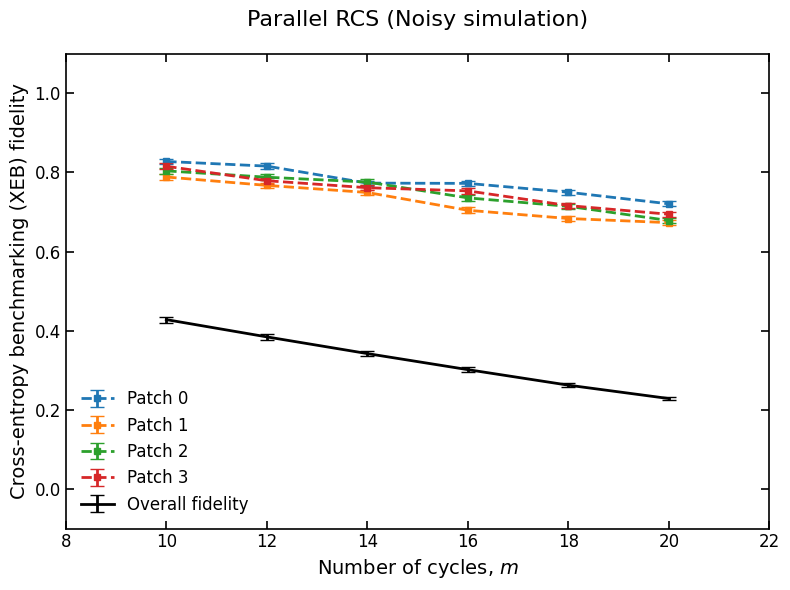

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Process and plot individual patches

means_matrix = np.zeros((len(patches), len(depths)))
errs_matrix = np.zeros((len(patches), len(depths)))
for i in range(len(patches)):
    y_means = []
    y_errs = []
    for j, d in enumerate(depths):
        fids = fidelities[(i, d)]
        mean_val = np.mean(fids)
        err_val = np.std(fids, ddof=1) / np.sqrt(num_instances)
        y_means.append(mean_val)
        y_errs.append(err_val)
        means_matrix[i, j] = mean_val
        errs_matrix[i, j] = err_val


    ax.errorbar(
        experiment.depths,
        means_matrix[i],
        yerr=errs_matrix[i],
        marker='s',
        markersize=4,
        linewidth=2,
        label=f'Patch {i}',
        linestyle='--',
        capsize=5,
        color=f'C{i}'
    )


# 2. Process and plot overall fidelity
overall_means_sim = []
overall_errs_sim = []

for j in range(len(depths)):
    f_tot = np.prod(means_matrix[:, j])
    overall_means_sim.append(f_tot)

    # Error propagation
    rel_errors_sq = (errs_matrix[:, j] / means_matrix[:, j])**2
    err_tot = f_tot * np.sqrt(np.sum(rel_errors_sq))
    overall_errs_sim.append(err_tot)

ax.errorbar(depths, overall_means_sim, yerr=overall_errs_sim, markersize=5,
            linewidth=2, label='Overall fidelity', linestyle='solid', color='k', capsize=5)


ax.set_ylim(-0.1, 1.1)
ax.set_xlim(min(experiment.depths) - 2, max(experiment.depths) + 2)
ax.set_xlabel(r'Number of cycles, $m$', fontsize=14)
ax.set_ylabel('Cross-entropy benchmarking (XEB) fidelity', fontsize=14)
ax.set_title('Parallel RCS (Noisy simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()

# Hardware demo

Now, let's perform the same experiment on real quantum hardware using [Quantum Engine](https://quantumai.google/cirq/google/engine) and see how it compares against the simulation.

In [ ]:
project_id = ""  # @param {type:"string"}
processor_name = ""  # @param {type:"string"}
config_name = ""  # @param {type:"string"}

engine = cirq_google.get_engine(project_id)
sampler_engine = engine.get_sampler(processor_name, device_config_name=config_name)

In [ ]:
# reload this to reset the random number generator
depths_engine = [10, 12, 14, 16, 18, 20]
experiment_engine = rcs.RCSExperiment(
    patches=patches,
    depths=depths_engine,
    num_instances=100,
    pattern_name="staggered",
    seed= 2026
)

In [ ]:
n_repetitions_engine = 10_000
results_engine = experiment_engine.run(
    sampler = sampler_engine,
    n_repetitions = n_repetitions_engine,
    characterize= True,
    theta=False,
    phi=True
)

fidelities_engine = results_engine.fidelities_lin()

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 207/207 [02:05<00:00,  1.66it/s]


Running 600 zipped instances on 4 parallel patches...


XEB Analysis: 100%|████████████████████████████████████████████████████████████████████████████████| 2400/2400 [01:46<00:00, 22.53it/s]


### Now we can plot the hardware data and compare against our earlier simulation.

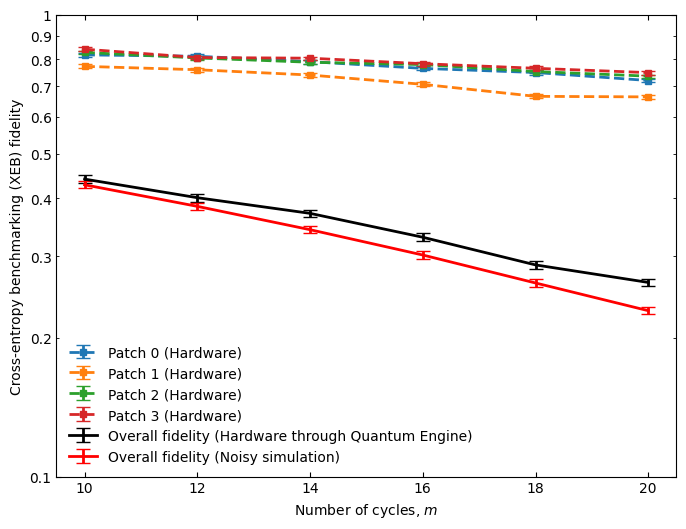

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Process and plot individual patches

means_matrix = np.zeros((len(patches), len(depths_engine)))
errs_matrix = np.zeros((len(patches), len(depths_engine)))
for i in range(len(patches)):
    y_means = []
    y_errs = []
    for j, d in enumerate(depths_engine):
        fids = fidelities_engine[(i, d)]
        mean_val = np.mean(fids)
        err_val = np.std(fids, ddof=1) / np.sqrt(num_instances)
        y_means.append(mean_val)
        y_errs.append(err_val)
        means_matrix[i, j] = mean_val
        errs_matrix[i, j] = err_val


    ax.errorbar(
        experiment_engine.depths,
        means_matrix[i],
        yerr=errs_matrix[i],
        marker='s',
        markersize=4,
        linewidth=2,
        label=f'Patch {i} (Hardware)',
        linestyle='--',
        capsize=5,
        color=f'C{i}'
    )


# 2. Process and plot overall fidelity
overall_means_engine = []
overall_errs_engine = []

for j in range(len(depths_engine)):
    f_tot = np.prod(means_matrix[:, j])
    overall_means_engine.append(f_tot)

    # Error propagation
    rel_errors_sq = (errs_matrix[:, j] / means_matrix[:, j])**2
    err_tot = f_tot * np.sqrt(np.sum(rel_errors_sq))
    overall_errs_engine.append(err_tot)

ax.errorbar(depths_engine, overall_means_engine, yerr=overall_errs_engine, markersize=5,
            linewidth=2, label='Overall fidelity (Hardware through Quantum Engine)', linestyle='solid', color='k', capsize=5)


ax.errorbar(depths, overall_means_sim, yerr=overall_errs_sim, markersize=5,
            linewidth=2, label='Overall fidelity (Noisy simulation)', linestyle='solid', color='r', capsize=5)


ax.set_xlabel(r'Number of cycles, $m$')
ax.set_ylabel('Cross-entropy benchmarking (XEB) fidelity')
ax.legend(frameon=False)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    which='both'
)
ax.set_yscale('log')
ax.set_ylim(1e-1, 1)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.1g}'))
ax.yaxis.set_minor_formatter(ticker.StrMethodFormatter('{x:.1g}'))